In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

**Loading dataset**

In [2]:
df=pd.read_csv("/content/weatherHistory.csv")
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
96448,2016-09-09 19:00:00.000 +0200,Partly Cloudy,rain,26.016667,26.016667,0.43,10.9963,31.0,16.1000,0.0,1014.36,Partly cloudy starting in the morning.
96449,2016-09-09 20:00:00.000 +0200,Partly Cloudy,rain,24.583333,24.583333,0.48,10.0947,20.0,15.5526,0.0,1015.16,Partly cloudy starting in the morning.
96450,2016-09-09 21:00:00.000 +0200,Partly Cloudy,rain,22.038889,22.038889,0.56,8.9838,30.0,16.1000,0.0,1015.66,Partly cloudy starting in the morning.
96451,2016-09-09 22:00:00.000 +0200,Partly Cloudy,rain,21.522222,21.522222,0.60,10.5294,20.0,16.1000,0.0,1015.95,Partly cloudy starting in the morning.


In [3]:
df.head(10)

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
0,2006-04-01 00:00:00.000 +0200,Partly Cloudy,rain,9.472222,7.388889,0.89,14.1197,251.0,15.8263,0.0,1015.13,Partly cloudy throughout the day.
1,2006-04-01 01:00:00.000 +0200,Partly Cloudy,rain,9.355556,7.227778,0.86,14.2646,259.0,15.8263,0.0,1015.63,Partly cloudy throughout the day.
2,2006-04-01 02:00:00.000 +0200,Mostly Cloudy,rain,9.377778,9.377778,0.89,3.9284,204.0,14.9569,0.0,1015.94,Partly cloudy throughout the day.
3,2006-04-01 03:00:00.000 +0200,Partly Cloudy,rain,8.288889,5.944444,0.83,14.1036,269.0,15.8263,0.0,1016.41,Partly cloudy throughout the day.
4,2006-04-01 04:00:00.000 +0200,Mostly Cloudy,rain,8.755556,6.977778,0.83,11.0446,259.0,15.8263,0.0,1016.51,Partly cloudy throughout the day.
5,2006-04-01 05:00:00.000 +0200,Partly Cloudy,rain,9.222222,7.111111,0.85,13.9587,258.0,14.9569,0.0,1016.66,Partly cloudy throughout the day.
6,2006-04-01 06:00:00.000 +0200,Partly Cloudy,rain,7.733333,5.522222,0.95,12.3648,259.0,9.9820,0.0,1016.72,Partly cloudy throughout the day.
7,2006-04-01 07:00:00.000 +0200,Partly Cloudy,rain,8.772222,6.527778,0.89,14.1519,260.0,9.9820,0.0,1016.84,Partly cloudy throughout the day.
8,2006-04-01 08:00:00.000 +0200,Partly Cloudy,rain,10.822222,10.822222,0.82,11.3183,259.0,9.9820,0.0,1017.37,Partly cloudy throughout the day.
9,2006-04-01 09:00:00.000 +0200,Partly Cloudy,rain,13.772222,13.772222,0.72,12.5258,279.0,9.9820,0.0,1017.22,Partly cloudy throughout the day.


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96453 entries, 0 to 96452
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Formatted Date            96453 non-null  object 
 1   Summary                   96453 non-null  object 
 2   Precip Type               95936 non-null  object 
 3   Temperature (C)           96453 non-null  float64
 4   Apparent Temperature (C)  96453 non-null  float64
 5   Humidity                  96453 non-null  float64
 6   Wind Speed (km/h)         96453 non-null  float64
 7   Wind Bearing (degrees)    96453 non-null  float64
 8   Visibility (km)           96453 non-null  float64
 9   Loud Cover                96453 non-null  float64
 10  Pressure (millibars)      96453 non-null  float64
 11  Daily Summary             96453 non-null  object 
dtypes: float64(8), object(4)
memory usage: 8.8+ MB


In [5]:
df.shape

(96453, 12)

In [7]:
#checking missing values
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,517
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


In [14]:
#handling missing values
df['Precip Type'] = df['Precip Type'].interpolate().bfill().ffill()
df["Precip Type"]

/tmp/ipykernel_2567/3456443722.py:2: FutureWarning: Series.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  df['Precip Type'] = df['Precip Type'].interpolate().bfill().ffill()


,Precip Type
0,rain
1,rain
2,rain
3,rain
4,rain
...,...
96448,rain
96449,rain
96450,rain
96451,rain


interpolation

Because this is weather time-series data, I would use interpolation rather than simply deleting those rows.

In [15]:
df.isnull().sum()

,0
Formatted Date,0
Summary,0
Precip Type,0
Temperature (C),0
Apparent Temperature (C),0
Humidity,0
Wind Speed (km/h),0
Wind Bearing (degrees),0
Visibility (km),0
Loud Cover,0


**Convert Date to Datetime**

In [17]:
df["Formatted Date"] = pd.to_datetime(df['Formatted Date'])

/tmp/ipykernel_2567/3358184624.py:1: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df["Formatted Date"] = pd.to_datetime(df['Formatted Date'])


In [19]:
df = df.sort_values('Formatted Date')
df

,Formatted Date,Summary,Precip Type,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars),Daily Summary
2880,2006-01-01 00:00:00+01:00,Partly Cloudy,rain,0.577778,-4.050000,0.89,17.1143,140.0,9.9820,0.0,1016.66,Mostly cloudy throughout the day.
2881,2006-01-01 01:00:00+01:00,Mostly Cloudy,rain,1.161111,-3.238889,0.85,16.6152,139.0,9.9015,0.0,1016.15,Mostly cloudy throughout the day.
2882,2006-01-01 02:00:00+01:00,Mostly Cloudy,rain,1.666667,-3.155556,0.82,20.2538,140.0,9.9015,0.0,1015.87,Mostly cloudy throughout the day.
2883,2006-01-01 03:00:00+01:00,Overcast,rain,1.711111,-2.194444,0.82,14.4900,140.0,9.9015,0.0,1015.56,Mostly cloudy throughout the day.
2884,2006-01-01 04:00:00+01:00,Mostly Cloudy,rain,1.183333,-2.744444,0.86,13.9426,134.0,9.9015,0.0,1014.98,Mostly cloudy throughout the day.
...,...,...,...,...,...,...,...,...,...,...,...,...
89728,2016-12-31 19:00:00+01:00,Mostly Cloudy,rain,0.488889,-2.644444,0.86,9.7566,167.0,8.0178,0.0,1020.03,Mostly cloudy throughout the day.
89729,2016-12-31 20:00:00+01:00,Mostly Cloudy,rain,0.072222,-3.050000,0.88,9.4185,169.0,7.2450,0.0,1020.27,Mostly cloudy throughout the day.
89730,2016-12-31 21:00:00+01:00,Mostly Cloudy,snow,-0.233333,-3.377778,0.89,9.2736,175.0,9.5795,0.0,1020.50,Mostly cloudy throughout the day.
89731,2016-12-31 22:00:00+01:00,Mostly Cloudy,snow,-0.472222,-3.644444,0.91,9.2414,182.0,8.4042,0.0,1020.65,Mostly cloudy throughout the day.


**Temperature Trend Over Time**

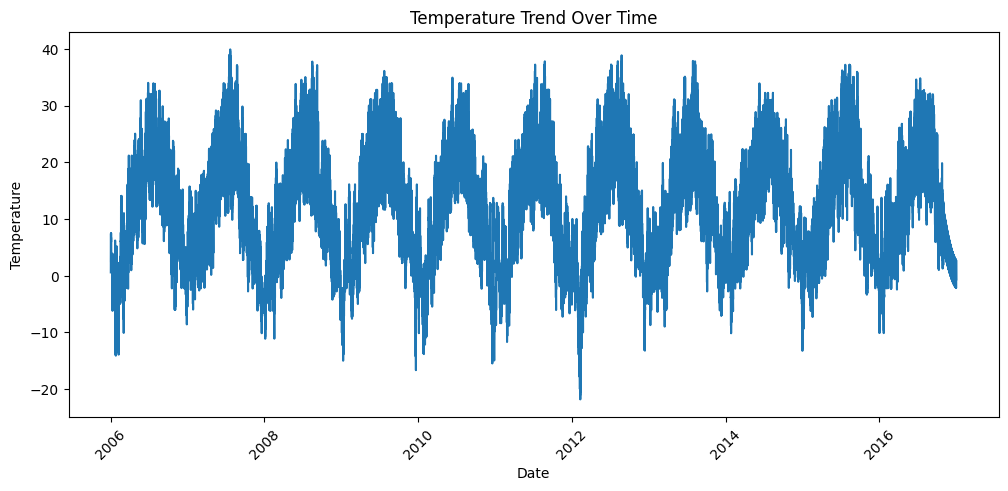

In [21]:
#plotting
plt.figure(figsize=(12, 5))
plt.plot(df['Formatted Date'], df['Temperature (C)'])
plt.xlabel('Date')
plt.ylabel('Temperature')
plt.title('Temperature Trend Over Time')

plt.xticks(rotation=45)
plt.show()

**Select Features and Target**

In [23]:
features = ['Temperature (C)', 'Humidity', 'Wind Speed (km/h)']
target = 'Temperature (C)'

data= df[features].copy()

**Normalization**

In [24]:
scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(data)

In [25]:
scaled_df = pd.DataFrame(scaled_data,columns=features)
scaled_df.head()

,Temperature (C),Humidity,Wind Speed (km/h)
0,0.362884,0.89,0.268028
1,0.372334,0.85,0.260212
2,0.380524,0.82,0.317196
3,0.381244,0.82,0.226929
4,0.372694,0.86,0.218356


In [26]:
#defining sequence length
sequence_length = 7

**create input sequences**

In [27]:
X = []
y = []
for i in range(sequence_length,len(scaled_data)):
    X.append(scaled_data[i-sequence_length:i])
    y.append(scaled_data[i, 0])

In [28]:
X = np.array(X)
y = np.array(y)

**Split Train, Validation and Test**

In [29]:
from sklearn.model_selection import train_test_split

# Split into training data (70%) and remaining data (30%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, shuffle=False)

# Split the remaining 30% into validation (15%) and testing (15%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, shuffle=False)

**Build SimpleRNN Model**

In [30]:
model = keras.Sequential([
    layers.Input(shape=(sequence_length, len(features))),
    layers.SimpleRNN(32, activation='tanh'),
    layers.Dropout(0.2),
    layers.Dense(1)])

In [32]:
#model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 32)             │         1,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,185 (4.63 KB)

 Trainable params: 1,185 (4.63 KB)

 Non-trainable params: 0 (0.00 B)

**compile the model**

In [33]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])

**Train the model**

In [35]:
history = model.fit(X_train,y_train,validation_data=(X_val, y_val),epochs=50,batch_size=32)

Epoch 1/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - loss: 6.6206e-04 - mae: 0.0188 - val_loss: 2.8626e-04 - val_mae: 0.0121
Epoch 2/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 14s 4ms/step - loss: 6.6394e-04 - mae: 0.0188 - val_loss: 2.7836e-04 - val_mae: 0.0120
Epoch 3/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - loss: 6.6603e-04 - mae: 0.0189 - val_loss: 2.6851e-04 - val_mae: 0.0125
Epoch 4/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.6140e-04 - mae: 0.0188 - val_loss: 2.6005e-04 - val_mae: 0.0120
Epoch 5/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 6.5947e-04 - mae: 0.0188 - val_loss: 2.6880e-04 - val_mae: 0.0119
Epoch 6/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 23s 7ms/step - loss: 6.6134e-04 - mae: 0.0188 - val_loss: 2.6496e-04 - val_mae: 0.0121
Epoch 7/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - loss: 6.5851e-04 - mae: 0.0188 - val_loss: 2.7825e-04 - val_mae: 0.0120
Epoch 8/50
2110/2110 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 6.6025e-04 - mae: 0.0188 - val_loss:

**training vs validation loss**

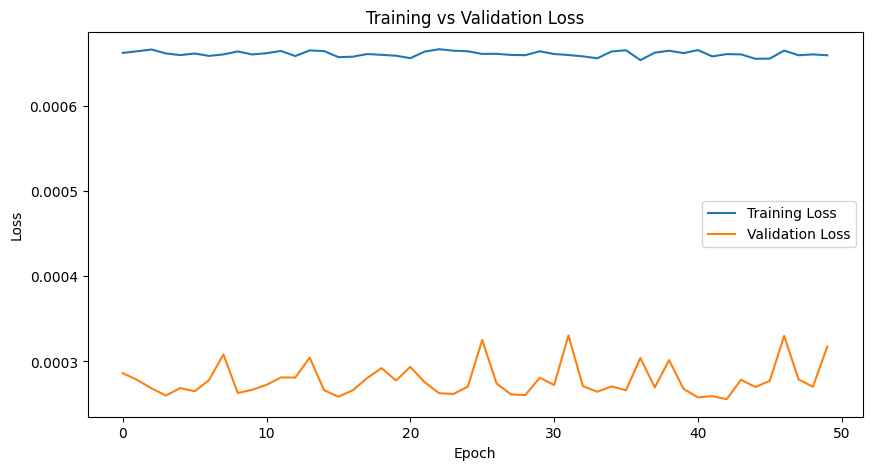

In [36]:
plt.figure(figsize=(10, 5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')

plt.legend()
plt.show()

**predict**

In [37]:
y_pred = model.predict(X_test)

453/453 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


**Convert Predictions Back to Original Scale**

In [38]:
temperature_min = scaler.data_min_[0]
temperature_max = scaler.data_max_[0]

y_test_original = (
    y_test * (temperature_max - temperature_min)
    + temperature_min
)

y_pred_original = (
    y_pred.flatten() * (temperature_max - temperature_min)
    + temperature_min
)

In [39]:
#calculate RSME
rmse = np.sqrt(
    mean_squared_error(y_test_original, y_pred_original)
)

print(rmse)

1.1238983816116355


In [40]:
#calculate mae
mae = mean_absolute_error(
    y_test_original,
    y_pred_original
)

print(mae)

0.8673597999470941


In [41]:
#calculate R2
r2 = r2_score(
    y_test_original,
    y_pred_original
)

print("R² Score:", r2)

R² Score: 0.98521395488876


actual vs predicted outcomes


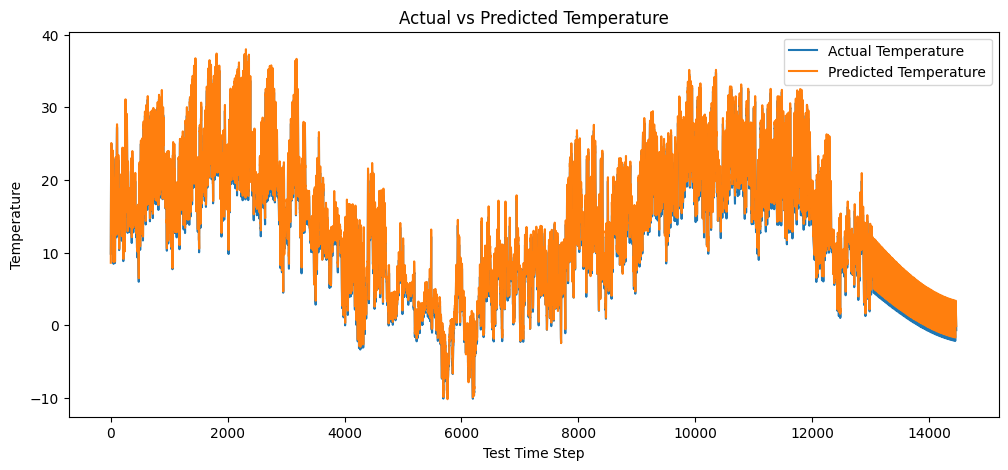

In [42]:
plt.figure(figsize=(12, 5))

plt.plot(y_test_original, label='Actual Temperature')
plt.plot(y_pred_original, label='Predicted Temperature')

plt.xlabel('Test Time Step')
plt.ylabel('Temperature')
plt.title('Actual vs Predicted Temperature')

plt.legend()
plt.show()

forcast next 7 days

In [43]:
last_sequence = scaled_data[-sequence_length:].copy()

print(last_sequence.shape)

(7, 3)


In [44]:
last_7_days = scaled_data[-7:]

forecast = []
for i in range(7):
    input_data = last_7_days.reshape(1, 7, 3)
    prediction = model.predict(input_data, verbose=0)
    forecast.append(prediction[0][0])
    new_day = last_7_days[-1].copy()
    new_day[0] = prediction[0][0]

    last_7_days = np.vstack([last_7_days[1:], new_day])

Convert Forecast Back to Temperature

In [45]:
forecast = np.array(forecast)

forecast_temperature = scaler.inverse_transform(
    np.column_stack((forecast, np.zeros((7, 2))))
)[:, 0]

print("Next 7 Days Temperature Forecast:")
print(forecast_temperature)

Next 7 Days Temperature Forecast:
[-0.26273138  0.29445978  1.02404645  1.89454518  2.86240088  3.90651296
  4.99513676]


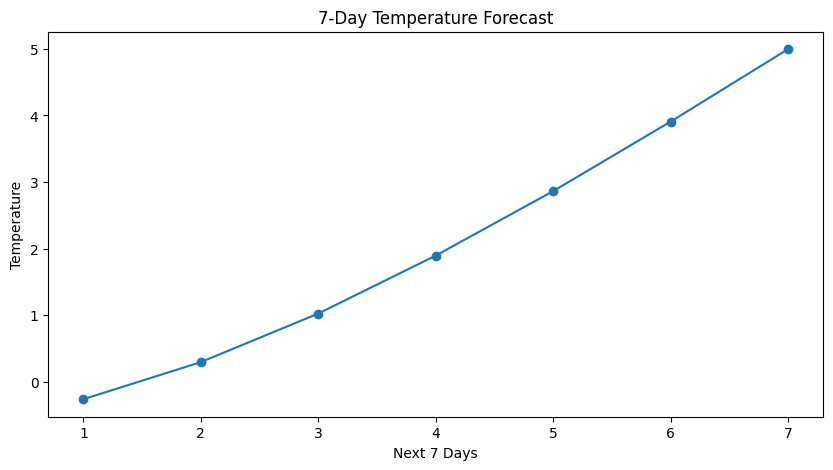

In [46]:
#plot forcast
plt.figure(figsize=(10, 5))

plt.plot(range(1, 8), forecast_temperature, marker='o')

plt.xlabel('Next 7 Days')
plt.ylabel('Temperature')
plt.title('7-Day Temperature Forecast')

plt.show()